# ARIM-Academy：CNNによるSEM画像からのナノ構造体の分類 ― LeNet-5で学ぶCNNの原点とKerasの文法
### 機器：走査電子顕微鏡（SEM）
### 分析：畳み込みニューラルネットワーク（CNN）LeNet-5

## このノートブックについて

| 項目 | 内容 |
| --- | --- |
| **対象読者** | ARIMデータポータル会員の研究者・技術者。Pythonの基礎文法（変数・関数・for文・リスト）は理解している方 |
| **前提知識** | 機械学習・深層学習の予備知識は前提としません。本書がシリーズの入口です |
| **学べること** | ①CNNという発想がどこから来たのかという歴史的経緯、②**Kerasでニューラルネットワークを組み立てる文法**（Sequential API / Functional API / compile・fit・evaluate・predict / コールバック / 保存と読込）、③層を1つ通るたびにデータの形がどう変わるかを手計算で追う方法、④1998年の設計を現代化すると何がどれだけ効くか |
| **動作環境** | Google Colab（GPU無しでも動きます）または ローカルの Python 3.10+ / TensorFlow 2.16+ / OpenCV / scikit-learn / pandas / matplotlib / seaborn |
| **所要時間** | 約15〜20分（本書のモデルは小さいのでCPUでも完走できます） |
| **データのライセンス** | 原データセットは CC BY 4.0（Aversa et al., *Sci Data* 5, 180172, 2018） |
| **本ノートブックのライセンス** | MIT License |
| **バージョン** | 第1版（2026-07-26） |

### シリーズ全3冊の地図

| # | ノートブック | ねらい |
| --- | --- | --- |
| 1 | `1_LeNet-5.ipynb` ←**本書** | **歴史編・文法編**：1998年のLeNet-5を原典に忠実に再現し、Kerasで層を組む文法を1つずつ習得する |
| 2 | `2_CNN.ipynb` | **現代化編**：LeNet-5を出発点に、解像度・活性化関数・プーリング・正則化を現代的な設計へ更新し、ハイパーパラメータを探索する |
| 3 | `3_Xception.ipynb` | **転移学習編**：ImageNetで事前学習されたXceptionを流用し、ゼロから学習したCNNと比較する |

3冊は**この順に読む前提**で書かれています。前の冊で導入した用語・評価の枠組み（多数派ベースライン、balanced accuracy、macro-F1、訓練/検証/テストの3分割）は、後の冊でも同じ意味で使います。ただしコードはそれぞれ独立して実行できるよう、セットアップとデータ読み込みは各冊に再掲しています。

### 本書の位置づけ ― なぜ最初に「古いモデル」を学ぶのか

深層学習の入門書はしばしば、いきなり現代的なCNNの完成形を提示します。しかしそれでは「なぜこの層がここにあるのか」「なぜ活性化関数はReLUなのか」が、先験的な決まりごとに見えてしまいます。

本書では逆の順序をとります。**1998年のLeNet-5を原典に忠実に組み立て**、それがどこで行き詰まるかを実際に走らせて確かめ、**部品を1つずつ入れ替えて効果を測る**という方法で進めます。この過程を経ると、次の `2_CNN.ipynb` に出てくる設計上の選択が、すべて「LeNet-5からの改善」として読めるようになります。

同時に本書は、**Kerasの文法を身につけるためのnotebook**でもあります。LeNet-5は層が7つしかなく、全パラメータを手計算で検算できる規模です。この小ささを活かして、`model.summary()` の1行1行が何を意味するのかを、電卓レベルの計算と突き合わせて確認していきます。

## 1. CNNの原点 ― LeNet-5とは何だったのか

### 1.1 時代背景

1980年代の画像認識は、研究者が手作業で「特徴量」を設計するのが常識でした。エッジの本数、輪郭の曲率、投影ヒストグラム……そうした人手の特徴量を作り、その上に分類器を載せます。特徴量の設計こそが研究の中身であり、うまくいくかどうかは設計者の勘に依存していました。

Yann LeCun らのグループはこれに対し、**特徴量そのものを学習で獲得させる**アプローチをとりました。1989年に誤差逆伝播法を手書き数字認識に適用した研究を発表し、その集大成として1998年に *Proceedings of the IEEE* へ発表されたのが **LeNet-5** です[1]。米国の郵便番号読み取りや銀行小切手の自動処理に実際に使われた、産業応用としても成功した最初期の深層モデルでした。

### 1.2 LeNet-5が持ち込んだ3つの考え方

今日のあらゆるCNNが受け継いでいる発想は、この時点でほぼ出揃っています。

| 考え方 | 内容 | なぜ効くのか |
| --- | --- | --- |
| **局所受容野**（local receptive field） | 各ニューロンは画像全体ではなく、5×5などの小さな窓だけを見る | 画像の情報は近くの画素どうしで強く相関する。遠く離れた画素との結合は無駄が多い |
| **重み共有**（weight sharing） | 同じフィルタを画像全体でスライドさせて使い回す | 「エッジを検出する」という機能は画像のどこでも同じ。位置ごとに別々のパラメータを持つ必要がない。パラメータ数が劇的に減る |
| **サブサンプリング**（subsampling） | 特徴マップを段階的に縮小する | 少しの位置ずれに鈍感になり（平行移動不変性）、同時に受容野が実質的に広がって大域的な形が見えてくる |

全結合ネットワークで32×32の画像を扱うと、入力層だけで1,024個のニューロンが必要で、次の層とのつながりは数十万本になります。LeNet-5は上の3つの工夫により、**わずか約60,000個の学習パラメータ**で当時最高水準の精度を出しました。この「パラメータを増やさずに表現力を得る」という発想が、CNNの核心です。

### 1.3 LeNet-5の構造

LeNet-5は7つの層からなります（入力層を除く）。慣例に従い、畳み込み層を C、サブサンプリング層を S、全結合層を F と呼びます。

### 図1：LeNet-5のアーキテクチャ

次のセルで、LeNet-5の構造を図示します（原論文の図の模写ではなく、matplotlibで描いたオリジナルの図です）。

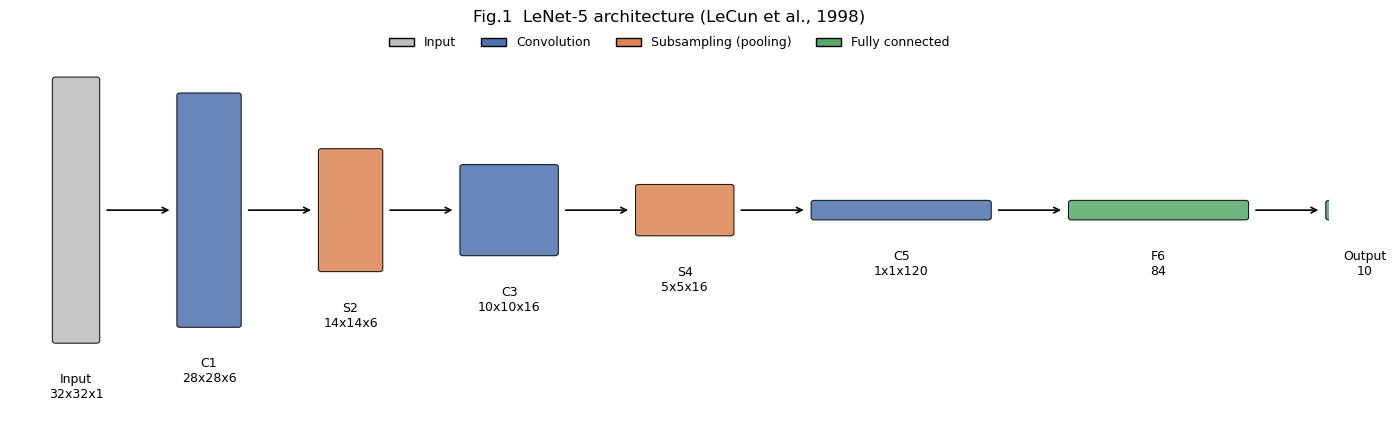

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 各層の (表示名, 幅, 高さ, チャンネル数, 説明)
architecture = [
    ("Input\n32x32x1",     32,  32,   1, "input"),
    ("C1\n28x28x6",        28,  28,   6, "conv"),
    ("S2\n14x14x6",        14,  14,   6, "pool"),
    ("C3\n10x10x16",       10,  10,  16, "conv"),
    ("S4\n5x5x16",          5,   5,  16, "pool"),
    ("C5\n1x1x120",         1,   1, 120, "conv"),
    ("F6\n84",              1,   1,  84, "dense"),
    ("Output\n10",          1,   1,  10, "dense"),
]
palette = {"input": "#BDBDBD", "conv": "#4C72B0", "pool": "#DD8452", "dense": "#55A868"}

fig, ax = plt.subplots(figsize=(14, 4.5))
x_cursor = 0.0
for name, width, height, channels, kind in architecture:
    # 特徴マップの大きさを高さで、チャンネル数を横幅（重なった枚数）で表現する
    box_height = 0.06 + height / 32 * 2.2
    box_width = 0.25 + min(channels, 40) / 40 * 0.9
    ax.add_patch(patches.FancyBboxPatch(
        (x_cursor, 1.6 - box_height / 2), box_width, box_height,
        boxstyle="round,pad=0.02", facecolor=palette[kind],
        edgecolor="black", linewidth=0.8, alpha=0.85))
    ax.text(x_cursor + box_width / 2, 1.6 - box_height / 2 - 0.28, name,
            ha="center", va="top", fontsize=9)
    x_cursor += box_width + 0.55

# 層のあいだの矢印
x_cursor = 0.0
for index, (name, width, height, channels, kind) in enumerate(architecture[:-1]):
    box_width = 0.25 + min(channels, 40) / 40 * 0.9
    ax.annotate("", xy=(x_cursor + box_width + 0.5, 1.6), xytext=(x_cursor + box_width + 0.05, 1.6),
                arrowprops=dict(arrowstyle="->", lw=1.2))
    x_cursor += box_width + 0.55

ax.set_xlim(-0.3, x_cursor)
ax.set_ylim(-0.3, 3.2)
ax.axis("off")
handles = [patches.Patch(facecolor=color, edgecolor="black", label=label)
           for label, color in [("Input", palette["input"]), ("Convolution", palette["conv"]),
                                ("Subsampling (pooling)", palette["pool"]),
                                ("Fully connected", palette["dense"])]]
ax.legend(handles=handles, loc="upper center", ncol=4, frameon=False, fontsize=9)
ax.set_title("Fig.1  LeNet-5 architecture (LeCun et al., 1998)", fontsize=12, pad=2)
fig.tight_layout()
plt.show()

### 1.4 原典と現代の実装の違い

ここが本書でいちばん重要な注意点です。**世の中で「LeNet-5」として実装されているコードの多くは、原典そのものではありません。** 1998年当時にあって現在のフレームワークに無い仕組みが3つあり、実装時に置き換えられているためです。

| | 原典（LeCun et al., 1998） | 現代のKerasでの一般的な実装 | 置き換えの理由 |
| --- | --- | --- | --- |
| **活性化関数** | スケーリング付き双曲線正接 $1.7159\tanh(\frac{2}{3}x)$ | `tanh`（本書）または `relu` | 係数は経験的な調整値。Keras標準の`tanh`で本質は変わらない |
| **S2 / S4** | 2×2の平均を取り、**学習可能な係数を掛けてバイアスを足し**、活性化関数を通す | `AveragePooling2D`（学習パラメータなし） | Kerasの標準プーリング層に学習パラメータが無い。S2で12個、S4で32個のパラメータが減る |
| **C3の結合** | S2の6枚の特徴マップのうち、**一部の組み合わせだけ**に接続する疎結合テーブル | `Conv2D`（全チャンネルに接続） | 疎結合は当時の計算量削減と「対称性を崩す」ための工夫。標準の`Conv2D`は全結合 |
| **出力層** | RBF層（ユークリッド距離ベース、パラメータは固定） | `Dense(10)` + softmax | RBF層は現在ほぼ使われない。交差エントロピー損失との相性でDenseが標準 |

**本書の方針**：Kerasの標準部品で組める範囲で原典の構造（層数・特徴マップ数・カーネルサイズ・活性化関数の種類・プーリングの種類）を忠実に再現し、**上記の差分は隠さず明示します**。パラメータ数の内訳も後で数値で突き合わせます。

[1] Y. LeCun, L. Bottou, Y. Bengio, P. Haffner, *Gradient-based learning applied to document recognition*, **Proceedings of the IEEE 86(11), 2278–2324 (1998)**, DOI: [10.1109/5.726791](https://doi.org/10.1109/5.726791)

## 2. セットアップ

### Google Colab で実行する場合

<font color="red">ローカル環境で実行する場合は、このセルを実行する必要はありません。</font>

In [ ]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    REPO_NAME = "Advanced_Tutorial_1_SEM-Image-Classification"
    if not Path(REPO_NAME).exists():
        !git clone --depth 1 https://github.com/ARIM-Academy-ImageRecognition/Advanced_Tutorial_1_SEM-Image-Classification.git
    %cd {REPO_NAME}

print(f"Running on Google Colab: {IN_COLAB}")
print(f"Current working directory: {Path.cwd()}")

Running on Google Colab: False
Current working directory: C:\Users\japan\Dropbox\ARIM\1_ARIM_Academy_2026\Advanced_Tutorial_9_SEM-Image-Classification


### ライブラリのインポートと共通設定

深層学習は乱数（重みの初期値、データのシャッフル順など）に依存します。結果を再現できるよう、乱数シードを一箇所にまとめて固定します。

> **注意**：GPU上の一部の演算は非決定的なため、シードを固定しても実行のたびに小数点以下が変動することがあります。「毎回まったく同じ数値になる」とは限りません。本書のモデルは小さいのでCPUでも十分動きます。

In [3]:
import os
import random
import time

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix, f1_score)
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version     : {keras.__version__}")
print(f"Random seed fixed to {SEED}")

ModuleNotFoundError: No module named 'cv2'

In [ ]:
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
TRAIN_DIR = DATA_DIR / "training_data"
PREDICT_DIR = DATA_DIR / "prediction_data"

OUTPUT_DIR = BASE_DIR / "output"
MODEL_DIR = BASE_DIR / "model"
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

assert TRAIN_DIR.exists(), f"Training data not found at {TRAIN_DIR}"

print(f"Data directory  : {TRAIN_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Model directory : {MODEL_DIR}")

## 3. データの準備

本シリーズは3冊とも、SEM（走査電子顕微鏡）で撮影されたナノ構造体の画像を10カテゴリに分類します。データセットの詳しい素性（出典・クラス不均衡・情報バーの問題）は `2_CNN.ipynb` で掘り下げますが、本書でも最低限の事実は確認しておきます。

**本書だけの特別な事情**：LeNet-5は**32×32ピクセルの入力**を前提に設計されたモデルです。C5層で特徴マップがちょうど1×1に収束するよう、カーネルサイズとプーリング回数が組んであります。したがって本書では、1,024×768のSEM画像を**32×32まで縮小**して使います。これは原典を忠実に再現するための選択であり、同時に「解像度を捨てると何が失われるか」を体感するための仕掛けでもあります。

In [ ]:
CATEGORIES = ["Biological", "Fibres",
              "Films_Coated_Surface", "MEMS_devices_and_electrodes",
              "Nanowires", "Particles",
              "Patterned_surface", "Porous_Sponge",
              "Powder", "Tips"]

NUM_CLASSES = len(CATEGORIES)

# LeNet-5 の原典が前提とする入力サイズ
IMG_SIZE = 32

# SEM画像の下部（636〜698行目）には測定条件を焼き込んだ情報バーがある。
# 残したまま学習させると、CNNが試料の形態ではなく文字を手がかりにしてしまう恐れがあるため切り落とす。
# （詳しい検証は 2_CNN.ipynb で行う）
DATABAR_TOP_ROW = 630


def load_micrograph(path, img_size=IMG_SIZE, crop_databar=True, as_rgb=False):
    """SEM画像を1枚読み込み、情報バーを除去して正方形にリサイズする。

    シリーズ3冊で共通の実装。縮小には INTER_AREA を使う
    （大きく縮めるときは既定の INTER_LINEAR よりエイリアシングが少ない）。
    """
    flag = cv2.IMREAD_COLOR if as_rgb else cv2.IMREAD_GRAYSCALE
    image = cv2.imread(str(path), flag)
    if image is None:
        raise ValueError(f"Failed to read image: {path}")

    if as_rgb:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    if crop_databar and image.shape[0] > DATABAR_TOP_ROW:
        image = image[:DATABAR_TOP_ROW, :]

    resized = cv2.resize(image, (img_size, img_size), interpolation=cv2.INTER_AREA)
    if not as_rgb:
        resized = resized[:, :, np.newaxis]
    return resized


def build_dataset(categories, img_size=IMG_SIZE, as_rgb=False, verbose=True):
    """カテゴリ別フォルダから全画像を読み込み、特徴量Xとラベルyを返す。"""
    images, labels, failures = [], [], []

    for class_index, category in enumerate(categories):
        paths = sorted((TRAIN_DIR / category).glob("*.jpg"))
        for path in paths:
            try:
                images.append(load_micrograph(path, img_size=img_size, as_rgb=as_rgb))
                labels.append(class_index)
            except ValueError as error:
                failures.append((path.name, str(error)))
        if verbose:
            print(f"  {category:30s} loaded {len(paths):4d} images")

    if failures:
        print(f"\nWARNING: {len(failures)} image(s) could not be read.")

    return np.stack(images).astype(np.uint8), np.asarray(labels, dtype=np.int64)


CACHE_PATH = OUTPUT_DIR / f"sem_dataset_gray_{IMG_SIZE}.npz"

start = time.time()
if CACHE_PATH.exists():
    with np.load(CACHE_PATH) as cached:
        X, y = cached["X"], cached["y"]
    print(f"Loaded cached dataset from {CACHE_PATH.name}")
else:
    X, y = build_dataset(CATEGORIES)
    np.savez_compressed(CACHE_PATH, X=X, y=y)
    print(f"Saved dataset cache to {CACHE_PATH.name}")

print(f"Elapsed: {time.time() - start:.1f} s")
print(f"X: shape={X.shape}, dtype={X.dtype}, range=[{X.min()}, {X.max()}]")

class_counts = pd.Series(y).value_counts().sort_index()
class_counts.index = CATEGORIES
majority_baseline = class_counts.max() / class_counts.sum()

print(f"\nTotal images: {class_counts.sum()}")
print(f"Majority-class baseline accuracy = {majority_baseline:.4f} "
      f"(always predicting '{class_counts.idxmax()}')")

### 多数派ベースラインという「ものさし」

上に表示された **0.5249** という数字を覚えておいてください。同梱データは `Powder` が全体の52.5%を占めるため、**何も学習せず常に `Powder` と答えるだけのモデル**でも正解率は52.5%になります。

つまり「正解率60%」という結果が出ても、それが学習の成果なのかは、この数字と比べるまで分かりません。本シリーズでは、正解率に加えて次の2つを必ず併記します。

- **balanced accuracy**：クラスごとの再現率の平均。少数クラスを無視すると下がる
- **macro-F1**：クラスごとのF1スコアの単純平均。同じく全クラスを平等に扱う

（クラス不均衡の詳しい内訳と、それがなぜ生じているかは `2_CNN.ipynb` で扱います。）

### 図2：32×32に縮小すると何が失われるか

In [ ]:
sample_category = "Nanowires"
sample_path = sorted((TRAIN_DIR / sample_category).glob("*.jpg"))[0]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
for ax, size in zip(axes, [512, 128, 64, 32]):
    ax.imshow(load_micrograph(sample_path, img_size=size).squeeze(), cmap="gray")
    ax.set_title(f"{size} x {size}" + ("  <- LeNet-5 input" if size == 32 else ""), fontsize=10)
    ax.axis("off")
fig.suptitle(f"Fig.2  Loss of detail when downscaling a micrograph ({sample_category})", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig02_downscaling.png", dpi=150, bbox_inches="tight")
plt.show()

ナノワイヤの1本1本は32×32では完全に潰れ、「全体がざらついた明るい領域」という情報しか残りません。**この時点で、SEM画像の分類にとって32×32が厳しいことは目に見えています。** 本書ではあえてこの条件で原典を走らせ、次の `2_CNN.ipynb` で解像度を100×100へ上げたときにどれだけ改善するかを比較します。

### 図3：カテゴリ別の画像枚数

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
bar_colors = ["tab:red" if c in (class_counts.idxmax(), class_counts.idxmin()) else "tab:blue"
              for c in class_counts.index]
ax.bar(class_counts.index, class_counts.values, color=bar_colors)
ax.set_ylabel("Number of images")
ax.set_title(f"Fig.3  Number of images per category (n = {class_counts.sum()})")
ax.tick_params(axis="x", rotation=60)
for x, v in enumerate(class_counts.values):
    ax.text(x, v + 12, str(v), ha="center", fontsize=9)
plt.setp(ax.get_xticklabels(), ha="right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig03_class_distribution.png", dpi=150)
plt.show()

### データの3分割

機械学習では、データを3つに分けて使います。

| 分割 | 用途 | 割合 |
| --- | --- | --- |
| 訓練（train） | モデルの重みを学習する | 60% |
| 検証（validation） | 学習の打ち切り判断・設計の選択 | 20% |
| テスト（test） | 最後に一度だけ使う「最終試験」 | 20% |

**画像そのものではなくインデックスを分割**しているのは、シリーズ3冊で**まったく同じ画像がテストデータになる**ことを保証するためです。最後に表示されるチェックサムが3冊で一致すれば、比較が公平であることの証拠になります。

**`stratify=y` を指定する理由**：`Tips` は全体で10枚しかありません。単純なランダム分割では、訓練データに`Tips`が1枚も入らないという事故が起こり得ます。層化抽出を指定すると、各分割のクラス構成比が元データと同じになるよう調整されます。

In [ ]:
all_indices = np.arange(len(y))

idx_trainval, idx_test = train_test_split(
    all_indices, test_size=0.2, random_state=SEED, stratify=y)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=0.25, random_state=SEED, stratify=y[idx_trainval])

X_train, y_train = X[idx_train], y[idx_train]
X_val, y_val = X[idx_val], y[idx_val]
X_test, y_test = X[idx_test], y[idx_test]

# 分割が重複していないことを確認する（データリーケージの初歩的な検算）
assert len(set(idx_train) & set(idx_val)) == 0
assert len(set(idx_train) & set(idx_test)) == 0
assert len(set(idx_val) & set(idx_test)) == 0

for name, labels in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:5s}: {len(labels):5d} samples ({len(labels) / len(y):.0%})")

print(f"\nSplit checksum (sum of test indices) = {idx_test.sum()}")
print("-> This value must match the checksum printed in 2_CNN.ipynb and 3_Xception.ipynb.")

## 4. Kerasの文法 ― Sequential APIで層を積む

ここからが本書のもう一つの主題です。KerasでLeNet-5を組み立てながら、**1つ1つの層が何を受け取り、何を返すのか**を追いかけます。

### 4.1 Sequential API の基本形

`Sequential` は「層を1本道で順番に通す」ネットワークを作るための、最も単純な書き方です。書き方は2通りあります。

```python
# 書き方A：add() で1層ずつ足す
model = keras.Sequential()
model.add(layers.Input(shape=(32, 32, 1)))
model.add(layers.Conv2D(6, kernel_size=5))
...

# 書き方B：リストでまとめて渡す
model = keras.Sequential([
    layers.Input(shape=(32, 32, 1)),
    layers.Conv2D(6, kernel_size=5),
    ...
])
```

**どちらでも結果は同じです。** `for`ループで層を追加したいとき（`2_CNN.ipynb` のハイパーパラメータ探索がそうです）は書き方Aが便利で、構造が固定なら書き方Bのほうが見通しが良くなります。本書は解説のために書き方Aを使います。

### 4.2 `Conv2D` の引数を読む

```python
layers.Conv2D(filters=6, kernel_size=5, strides=1, padding="valid", activation="tanh")
```

| 引数 | 意味 | LeNet-5での値 |
| --- | --- | --- |
| `filters` | 出力する特徴マップの枚数。**フィルタ1枚が1種類の模様検出器**に対応する | C1では6、C3では16 |
| `kernel_size` | フィルタの一辺の大きさ。`5` は `(5, 5)` と同じ | 5 |
| `strides` | フィルタを何画素ずつずらすか | 1（既定値） |
| `padding` | `"valid"` は縁を埋めない（出力が小さくなる）、`"same"` は出力サイズを入力と同じに保つよう縁をゼロで埋める | `"valid"` |
| `activation` | 活性化関数。指定しなければ線形（恒等写像） | `"tanh"` |

### 4.3 出力サイズの計算式

畳み込み層・プーリング層を通ると、特徴マップの一辺の長さは次の式で決まります。

$$ W_{\text{out}} = \left\lfloor \frac{W_{\text{in}} - K + 2P}{S} \right\rfloor + 1 $$

ここで $W_{\text{in}}$ は入力の一辺、$K$ はカーネルサイズ、$P$ はパディング幅（`"valid"` なら0）、$S$ はストライドです。

**この式でLeNet-5の各層を手計算してみましょう。**

In [ ]:
def conv_output_size(input_size, kernel_size, padding=0, stride=1):
    """畳み込み／プーリング後の特徴マップの一辺の長さを返す。"""
    return (input_size - kernel_size + 2 * padding) // stride + 1


print("LeNet-5 の特徴マップサイズを手計算する")
print("-" * 58)
size = 32
print(f"{'Input':<26} {size:>2} x {size:>2}")

size = conv_output_size(size, kernel_size=5)                 # C1: 5x5 conv, valid
print(f"{'C1  Conv2D(6, 5, valid)':<26} {size:>2} x {size:>2}")

size = conv_output_size(size, kernel_size=2, stride=2)       # S2: 2x2 pooling
print(f"{'S2  AveragePooling2D(2)':<26} {size:>2} x {size:>2}")

size = conv_output_size(size, kernel_size=5)                 # C3
print(f"{'C3  Conv2D(16, 5, valid)':<26} {size:>2} x {size:>2}")

size = conv_output_size(size, kernel_size=2, stride=2)       # S4
print(f"{'S4  AveragePooling2D(2)':<26} {size:>2} x {size:>2}")

size = conv_output_size(size, kernel_size=5)                 # C5
print(f"{'C5  Conv2D(120, 5, valid)':<26} {size:>2} x {size:>2}")
print("-" * 58)
print("C5 でちょうど 1 x 1 に収束する -> これがLeNet-5が入力32x32を前提とする理由")

**この「ちょうど1×1」が、LeNet-5の設計の要です。** C5層に到達したとき特徴マップが1×1になるよう、入力サイズ32、カーネル5、プーリング2回が組み合わされています。入力を100×100にすると、同じ層構成でもC5の出力は22×22となり、続く全結合層のパラメータ数が跳ね上がります。**入力サイズを変えたければ層構成も設計し直す必要がある**——この事実は `2_CNN.ipynb` で解像度を上げるときに効いてきます。

### 4.4 パラメータ数の計算式

畳み込み層の学習パラメータ数は次式で求まります。

$$ (\underbrace{K \times K \times C_{\text{in}}}_{\text{フィルタ1枚の重み}} + \underbrace{1}_{\text{バイアス}}) \times C_{\text{out}} $$

全結合層は $(N_{\text{in}} + 1) \times N_{\text{out}}$ です。プーリング層には学習パラメータがありません（Kerasの標準実装の場合）。

In [ ]:
def conv_params(kernel_size, in_channels, out_channels):
    """畳み込み層の学習パラメータ数を返す（重み＋バイアス）。"""
    return (kernel_size * kernel_size * in_channels + 1) * out_channels


def dense_params(in_units, out_units):
    """全結合層の学習パラメータ数を返す（重み＋バイアス）。"""
    return (in_units + 1) * out_units


hand_calculation = [
    ("C1  Conv2D(6, 5)",     conv_params(5, 1, 6)),
    ("S2  AveragePooling2D", 0),
    ("C3  Conv2D(16, 5)",    conv_params(5, 6, 16)),
    ("S4  AveragePooling2D", 0),
    ("C5  Conv2D(120, 5)",   conv_params(5, 16, 120)),
    ("F6  Dense(84)",        dense_params(120, 84)),
    ("OUT Dense(10)",        dense_params(84, 10)),
]

print("Keras実装での学習パラメータ数（手計算）")
print("-" * 46)
for name, value in hand_calculation:
    print(f"{name:<26} {value:>10,}")
print("-" * 46)
expected_total_params = sum(value for _, value in hand_calculation)
print(f"{'Total':<26} {expected_total_params:>10,}")

### 4.5 LeNet-5を組み立てる

いよいよ実装です。1層ずつコメントを付けています。

In [ ]:
def build_lenet5(input_shape=(32, 32, 1), num_classes=10,
                 activation="tanh", pooling="average", name="lenet5"):
    """LeNet-5（LeCun et al., 1998）を Keras の Sequential API で構築する。

    activation と pooling を差し替えられるようにしてあるのは、
    第7章で「原典 vs 現代化」を比較するため。既定値は原典に忠実な設定。

    出力層は活性化関数を持たず、生のスコア（ロジット）を返す。
    """
    pooling_layer = layers.AveragePooling2D if pooling == "average" else layers.MaxPooling2D

    model = keras.Sequential(name=name)

    # --- 入力層：データの形だけを宣言する。学習パラメータは持たない ---
    model.add(layers.Input(shape=input_shape, name="input"))

    # --- 前処理をモデルに内蔵する ---
    # 0-255 の画素値を -1〜+1 に変換する。tanh は 0 付近で最も感度が高いため、
    # 入力を 0 中心に揃えると学習が進みやすい。
    # （原典も背景 -0.1 / 前景 1.175 と、およそ 0 中心になるよう正規化していた）
    model.add(layers.Rescaling(scale=1.0 / 127.5, offset=-1.0, name="rescaling"))

    # --- C1：畳み込み層。32x32x1 -> 28x28x6 ---
    model.add(layers.Conv2D(filters=6, kernel_size=5, strides=1, padding="valid",
                            activation=activation, name="C1_conv"))

    # --- S2：サブサンプリング層。28x28x6 -> 14x14x6 ---
    model.add(pooling_layer(pool_size=2, strides=2, name="S2_pool"))

    # --- C3：畳み込み層。14x14x6 -> 10x10x16 ---
    # 原典はS2の6枚のうち一部の組み合わせだけに接続する疎結合だったが、
    # ここでは標準の Conv2D（全チャンネル接続）を使う
    model.add(layers.Conv2D(filters=16, kernel_size=5, strides=1, padding="valid",
                            activation=activation, name="C3_conv"))

    # --- S4：サブサンプリング層。10x10x16 -> 5x5x16 ---
    model.add(pooling_layer(pool_size=2, strides=2, name="S4_pool"))

    # --- C5：畳み込み層。5x5x16 -> 1x1x120 ---
    # 特徴マップがちょうど1x1になるため実質的には全結合層だが、
    # 原典が畳み込み層として定義しているのに従う
    model.add(layers.Conv2D(filters=120, kernel_size=5, strides=1, padding="valid",
                            activation=activation, name="C5_conv"))

    # --- Flatten：(1, 1, 120) を (120,) に平坦化する。学習パラメータなし ---
    model.add(layers.Flatten(name="flatten"))

    # --- F6：全結合層。120 -> 84 ---
    model.add(layers.Dense(units=84, activation=activation, name="F6_dense"))

    # --- 出力層：84 -> 10（クラス数）---
    # 原典はRBF層。ここでは Dense を使い、活性化関数は付けずにロジットを出す
    model.add(layers.Dense(units=num_classes, name="output_logits"))

    return model


lenet = build_lenet5(input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=NUM_CLASSES)
lenet.summary()

### 4.6 `model.summary()` の読み方

上の表には3つの列があります。

- **Layer (type)**：層の名前と種類。`name=` で付けた名前がここに出ます
- **Output Shape**：その層を通ったあとのデータの形。先頭の `None` は**バッチサイズ**（何枚まとめて処理するかは実行時に決まる）を表します
- **Param #**：その層が持つ学習パラメータの個数

4.3節・4.4節で手計算した値と、`summary()` の表示が一致しているはずです。プログラムで突き合わせて確認しましょう。

In [ ]:
print("手計算とKerasの実装を突き合わせる")
print("=" * 62)
print(f"{'Layer':<20}{'Output shape':<20}{'Params (Keras)':>12}{'Hand':>10}")
print("-" * 62)

hand_lookup = dict(hand_calculation)
name_map = {"C1_conv": "C1  Conv2D(6, 5)", "S2_pool": "S2  AveragePooling2D",
            "C3_conv": "C3  Conv2D(16, 5)", "S4_pool": "S4  AveragePooling2D",
            "C5_conv": "C5  Conv2D(120, 5)", "F6_dense": "F6  Dense(84)",
            "output_logits": "OUT Dense(10)"}

for layer in lenet.layers:
    keras_params = layer.count_params()
    hand_value = hand_lookup.get(name_map.get(layer.name, ""), None)
    hand_text = f"{hand_value:,}" if hand_value is not None else "-"
    print(f"{layer.name:<20}{str(layer.output.shape):<20}{keras_params:>12,}{hand_text:>10}")

print("-" * 62)
print(f"{'Total':<40}{lenet.count_params():>12,}{expected_total_params:>10,}")

assert lenet.count_params() == expected_total_params, "手計算とKerasの値が一致しません"
print("\nOK: 手計算とKerasの実装が完全に一致しました。")

### 4.7 原典の60,000パラメータとの差分

原論文は「LeNet-5の学習パラメータは約60,000個」と記しています。本実装は 61,706 個で、**1,706個多い**。この差はすべて1.4節で挙げた置き換えから説明できます。

In [ ]:
original_breakdown = [
    ("C1  convolution",                 conv_params(5, 1, 6),  "同じ"),
    ("S2  subsampling (trainable)",     6 * 2,                 "特徴マップごとに係数1＋バイアス1"),
    ("C3  convolution (sparse table)",  1516,                  "疎結合テーブル（原典 Table I）"),
    ("S4  subsampling (trainable)",     16 * 2,                "特徴マップごとに係数1＋バイアス1"),
    ("C5  convolution",                 conv_params(5, 16, 120), "同じ"),
    ("F6  fully connected",             dense_params(120, 84), "同じ"),
    ("OUT RBF layer (fixed)",           0,                     "パラメータは固定で学習しない"),
]

print("原典 LeCun et al. (1998) の学習パラメータ内訳")
print("=" * 78)
for name, value, note in original_breakdown:
    print(f"{name:<34}{value:>8,}   {note}")
print("-" * 78)
original_total = sum(value for _, value, _ in original_breakdown)
print(f"{'Original total':<34}{original_total:>8,}   <- 論文の「約60,000個」と一致")
print(f"{'This Keras implementation':<34}{expected_total_params:>8,}")
print("=" * 78)

print(f"\n差分 {expected_total_params - original_total:+,} の内訳")
print(f"  C3 を疎結合から全結合に変更     : {conv_params(5, 6, 16) - 1516:+,}")
print(f"  サブサンプリングの学習係数が消失: {-(6 * 2 + 16 * 2):+,}")
print(f"  RBF出力層を Dense(10) に変更    : {dense_params(84, 10):+,}")
print(f"  合計                            : "
      f"{conv_params(5, 6, 16) - 1516 - (6 * 2 + 16 * 2) + dense_params(84, 10):+,}")

> **教材としての注記**：ここで示した「差分がぴったり説明できる」という事実は、実装が原典の構造を正しく再現できていることの強い傍証になります。深層学習のコードは間違っていても動いてしまうため、**このように検算できる箇所は必ず検算する**習慣が有効です。

## 5. Kerasの文法 ― Functional API との書き比べ

`Sequential` は「一本道」のネットワークしか作れません。分岐や合流（残差接続、複数入力・複数出力など）がある構造は書けないのです。そこで用意されているのが **Functional API** です。

書き方の違いは次のとおりです。

| | Sequential API | Functional API |
| --- | --- | --- |
| 考え方 | 層を**積む** | テンソルを層に**通す** |
| 書き方 | `model.add(layer)` | `x = layer(x)` |
| 入口・出口 | 暗黙 | `keras.Model(inputs, outputs)` で明示 |
| 分岐・合流 | 書けない | 書ける |

`3_Xception.ipynb` では、事前学習済みモデルの上に自分の層を載せるために Functional API を使います。ここでその読み方に慣れておきましょう。

**同じLeNet-5をFunctional APIで書き直し、パラメータ数が一致することを確かめます。**

In [ ]:
def build_lenet5_functional(input_shape=(32, 32, 1), num_classes=10,
                            activation="tanh", name="lenet5_functional"):
    """LeNet-5 を Functional API で構築する（build_lenet5 と等価）。

    Sequential との違いは「層を積む」のではなく
    「テンソル x を層に通して新しい x を得る」という書き方をする点。
    """
    # 入口となるテンソルを宣言する
    inputs = keras.Input(shape=input_shape, name="input")

    # テンソルを層に通していく。layer(x) の形が Functional API の基本
    x = layers.Rescaling(scale=1.0 / 127.5, offset=-1.0, name="rescaling")(inputs)
    x = layers.Conv2D(6, 5, padding="valid", activation=activation, name="C1_conv")(x)
    x = layers.AveragePooling2D(pool_size=2, strides=2, name="S2_pool")(x)
    x = layers.Conv2D(16, 5, padding="valid", activation=activation, name="C3_conv")(x)
    x = layers.AveragePooling2D(pool_size=2, strides=2, name="S4_pool")(x)
    x = layers.Conv2D(120, 5, padding="valid", activation=activation, name="C5_conv")(x)
    x = layers.Flatten(name="flatten")(x)
    x = layers.Dense(84, activation=activation, name="F6_dense")(x)
    outputs = layers.Dense(num_classes, name="output_logits")(x)

    # 入口と出口を指定してモデルを組み立てる
    return keras.Model(inputs=inputs, outputs=outputs, name=name)


lenet_functional = build_lenet5_functional(
    input_shape=(IMG_SIZE, IMG_SIZE, 1), num_classes=NUM_CLASSES)

print(f"Sequential API : {lenet.count_params():,} parameters")
print(f"Functional API : {lenet_functional.count_params():,} parameters")

# 層ごとに形とパラメータ数が一致するかを確認する
for sequential_layer, functional_layer in zip(lenet.layers, lenet_functional.layers[1:]):
    assert sequential_layer.count_params() == functional_layer.count_params()
    assert sequential_layer.output.shape == functional_layer.output.shape

print("\nOK: 2つの書き方は完全に等価なモデルを作ります。")
print("（Functional API では Input が layers に含まれるため、比較時に1つずらしています）")

> **どちらを使うべきか**：一本道なら `Sequential` のほうが簡潔で読みやすく、分岐が必要になった時点で `Functional` に移る、というのが実務的な使い分けです。本シリーズでは、`2_CNN.ipynb` が `Sequential`、`3_Xception.ipynb` が `Functional` を使います。

## 6. Kerasの文法 ― compile / fit / evaluate / predict

モデルの「形」ができたら、次は学習の手続きです。Kerasでは4つのメソッドが役割を分担しています。

| メソッド | 役割 | いつ呼ぶか |
| --- | --- | --- |
| `compile()` | **学習のルールを決める**：何を最小化するか（損失関数）、どう更新するか（最適化アルゴリズム）、何を記録するか（評価指標） | 学習の前に1回。`trainable` を変更したら**必ず呼び直す** |
| `fit()` | **実際に学習する**：訓練データを繰り返し流して重みを更新する | 学習時 |
| `evaluate()` | 損失と評価指標を**まとめて数値で**返す | 評価時 |
| `predict()` | 各サンプルに対する**出力そのもの**を返す | 予測時・詳細な分析時 |

### 6.1 `compile()` の3つの引数

```python
model.compile(optimizer=..., loss=..., metrics=[...])
```

**`loss`（損失関数）** — モデルの「間違い具合」を数値化する関数。分類問題では交差エントロピーを使います。ラベルの持ち方で名前が変わります。

| ラベルの形 | 使う損失関数 |
| --- | --- |
| 整数（`y = 3`）← 本シリーズ | `SparseCategoricalCrossentropy` |
| one-hot（`y = [0,0,0,1,0,...]`） | `CategoricalCrossentropy` |

**`from_logits` 引数**が重要です。本書の出力層は活性化関数を付けず、生のスコア（**ロジット**）を出しています。この場合 `from_logits=True` を指定すると、Kerasが内部で数値的に安定した形でソフトマックスと交差エントロピーをまとめて計算してくれます。出力層に `activation="softmax"` を付けた場合は `from_logits=False`（既定値）です。**どちらか一方**であり、両方やると二重にソフトマックスがかかって学習が壊れます。

**`optimizer`（最適化アルゴリズム）** — 損失を減らす方向へ重みをどう動かすか。

| | 特徴 | LeNet-5の時代 |
| --- | --- | --- |
| `SGD` | 素朴な勾配降下。学習率の調整が難しい | これが標準だった |
| `Adam` | 勾配の履歴から学習率をパラメータごとに自動調整する（2015年） | まだ存在しない |

本章では原典に合わせて `SGD` を使い、第7章で `Adam` に替えた効果を測ります。

**`metrics`（評価指標）** — 学習中に記録したい指標。損失と違って**学習には使われません**（人間が見るためのもの）。

In [ ]:
EPOCHS = 60
BATCH_SIZE = 32

lenet.compile(
    # 原典の時代に合わせて素朴な確率的勾配降下法を使う
    optimizer=keras.optimizers.SGD(learning_rate=0.05, momentum=0.9),
    # 出力層が活性化関数なし（ロジット）なので from_logits=True
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"])

print("Compiled.")
print(f"  optimizer : {lenet.optimizer.name}")
print(f"  loss      : {lenet.loss.name}")

### 6.2 `fit()` の引数と `history`

```python
history = model.fit(X_train, y_train, epochs=..., batch_size=..., validation_data=...)
```

- **`batch_size`**：一度に何枚まとめて処理し、何枚分の平均勾配で重みを1回更新するか。小さいほど更新回数が増えて学習は細かくなりますが、1エポックの時間は長くなります
- **`epochs`**：訓練データ全体を何周するか
- **`validation_data`**：各エポックの終わりに評価するデータ。**学習には使われません**。ここに渡した指標は `val_` の接頭辞が付きます

`fit()` の戻り値である `history` オブジェクトには、エポックごとの記録が辞書として入っています。これを使って学習曲線を描きます。

**`callbacks`（コールバック）** も指定します。学習の途中で自動的に処理を差し込む仕組みです。

- **`EarlyStopping`**：検証損失が改善しなくなったら学習を打ち切る。`restore_best_weights=True` を付けると、**最も良かった時点の重みに巻き戻して**終了します
- **`ModelCheckpoint`**：検証データで最良のモデルをファイルに保存する

この2つを併用するのが定石です。エポック数を多めに設定しておき、あとは EarlyStopping に任せます。

In [ ]:
checkpoint_path = MODEL_DIR / "lenet5_original.keras"

callbacks = [
    # 検証損失が8エポック改善しなければ打ち切り、最良時点の重みに戻す
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=8,
                                  restore_best_weights=True, verbose=1),
    # 検証損失が最良になるたびにファイルへ保存する
    keras.callbacks.ModelCheckpoint(checkpoint_path, monitor="val_loss",
                                    save_best_only=True, verbose=0),
]

start = time.time()
history_lenet = lenet.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=2)
elapsed = time.time() - start

print(f"\nTraining finished in {elapsed:.1f} s "
      f"({len(history_lenet.history['loss'])} epochs actually run out of {EPOCHS})")
print(f"history.history keys: {list(history_lenet.history.keys())}")

### 6.3 `evaluate()` と `predict()` の違い

同じモデル・同じデータでも、返ってくるものが違います。

- `evaluate()` → `[損失, 正解率]` のような**数値のリスト**（`compile` で指定した順）
- `predict()` → 各サンプルの**出力そのもの**（本書では10クラス分のロジット）

正解率だけ見たいなら `evaluate()`、混同行列やクラス別の分析をしたいなら `predict()` を使います。

In [ ]:
# evaluate: 数値のリストが返る
test_loss, test_accuracy = lenet.evaluate(X_test, y_test, verbose=0)
print(f"evaluate() -> loss={test_loss:.4f}, accuracy={test_accuracy:.4f}")

# predict: サンプルごとの出力が返る
logits = lenet.predict(X_test[:3], verbose=0)
print(f"\npredict() -> shape={logits.shape}  (3 samples x {NUM_CLASSES} classes)")
print("最初の1サンプルの生のロジット:")
print(np.round(logits[0], 3))

# ロジットは合計が1にならない。確率にするにはソフトマックスを通す
probabilities = tf.nn.softmax(logits[0]).numpy()
print("\nソフトマックスを通した確率:")
print(np.round(probabilities, 3))
print(f"合計 = {probabilities.sum():.6f}")
print(f"最も確率の高いクラス = {CATEGORIES[int(np.argmax(probabilities))]}")

### 6.4 モデルの保存と読み込み

学習したモデルは `.keras` 形式（Keras 3 の標準）で保存します。**構造・重み・最適化アルゴリズムの状態がすべて1ファイルに収まる**ため、読み込んだモデルはそのまま推論にも追加学習にも使えます。

In [ ]:
save_path = MODEL_DIR / "lenet5_original_final.keras"
lenet.save(save_path)
print(f"Saved: {save_path.name} ({save_path.stat().st_size / 1e3:.0f} KB)")

# 読み直して、まったく同じ予測を返すことを確認する
reloaded = keras.models.load_model(save_path)
original_logits = lenet.predict(X_test[:20], verbose=0)
reloaded_logits = reloaded.predict(X_test[:20], verbose=0)

max_difference = np.abs(original_logits - reloaded_logits).max()
print(f"Maximum difference after reload: {max_difference:.2e}")
assert max_difference < 1e-6
print("OK: 保存と読み込みで結果が変わらないことを確認しました。")

## 7. LeNet-5の成績を評価する

### 7.1 評価用のヘルパー関数

評価のたびに同じコードを書くのは間違いのもとです。関数にまとめます。ここで定義する関数は、シリーズ3冊で共通です。

In [ ]:
def predict_proba(model, features, batch_size=64):
    """モデルのロジット出力をソフトマックスで確率に変換して返す。"""
    logits = model.predict(features, batch_size=batch_size, verbose=0)
    return tf.nn.softmax(logits).numpy()


def evaluate_classifier(model, features, y_true, model_name, split_name):
    """分類モデルを評価し、主要指標を辞書で返す。"""
    y_proba = predict_proba(model, features)
    y_pred = np.argmax(y_proba, axis=1)

    scores = {
        "model": model_name,
        "split": split_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    return scores, y_pred, y_proba


def plot_confusion_matrix(y_true, y_pred, class_names, title, filename, normalize=True):
    """混同行列を描画して保存する。normalize=True では行方向に正規化する。"""
    # scikit-learn の規約どおり、第1引数が正解、第2引数が予測
    matrix = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))

    if normalize:
        row_sums = matrix.sum(axis=1, keepdims=True)
        display_matrix = np.divide(matrix, row_sums, where=row_sums != 0)
        fmt, vmax, cbar_label = ".2f", 1.0, "Recall (row-normalised)"
    else:
        display_matrix = matrix
        fmt, vmax, cbar_label = "d", None, "Number of images"

    fig, ax = plt.subplots(figsize=(8.5, 7))
    sns.heatmap(display_matrix, annot=True, fmt=fmt, square=True,
                cmap="Blues", vmin=0, vmax=vmax,
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={"label": cbar_label}, ax=ax)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=60, ha="right")
    plt.setp(ax.get_yticklabels(), rotation=0)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()
    return matrix


def plot_learning_curves(history, title, filename):
    """学習曲線（損失と正解率）を並べて描画する。"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

    axes[0].plot(history.history["loss"], color="black", label="training")
    axes[0].plot(history.history["val_loss"], color="red", label="validation")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history.history["accuracy"], color="black", label="training")
    axes[1].plot(history.history["val_accuracy"], color="red", label="validation")
    axes[1].axhline(majority_baseline, color="gray", ls="--",
                    label=f"majority baseline ({majority_baseline:.3f})")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=150)
    plt.show()

print("Helper functions defined.")

### 図4：LeNet-5の学習曲線

In [ ]:
plot_learning_curves(history_lenet,
                     "Fig.4  Learning curves of the original LeNet-5 (32x32 input, tanh, average pooling, SGD)",
                     "fig04_learning_curve_lenet.png")

### 7.2 評価と混同行列

In [ ]:
results = []

scores_val, _, _ = evaluate_classifier(lenet, X_val, y_val, "1: LeNet-5 (original)", "val")
scores_test, y_pred_lenet, _ = evaluate_classifier(
    lenet, X_test, y_test, "1: LeNet-5 (original)", "test")
results.extend([scores_val, scores_test])

print(pd.DataFrame([scores_val, scores_test]).round(4).to_string(index=False))
print(f"\nMajority-class baseline accuracy for reference: {majority_baseline:.4f}")
print()
print(classification_report(y_test, y_pred_lenet, labels=range(NUM_CLASSES),
                            target_names=CATEGORIES, digits=3, zero_division=0))

### 図5：LeNet-5の混同行列

行方向に正規化しているので、各行の値は「その真のクラスのうち、何割がその列に予測されたか」＝**クラスごとの再現率**です。対角成分が濃いほど良いモデルです。`Powder` の列に横一線の帯ができていたら、それは「迷ったら多数派を答える」という、クラス不均衡データで典型的な振る舞いです。

In [ ]:
_ = plot_confusion_matrix(y_test, y_pred_lenet, CATEGORIES,
                          "Fig.5  Confusion matrix of the original LeNet-5 (test set, row-normalised)",
                          "fig05_confusion_lenet.png")

## 8. 1998年の設計を現代化する ― ここが次の冊への橋

LeNet-5の成績は、多数派ベースラインは上回るものの、実用には遠い水準にとどまるはずです。**では、どこを直せばよいのでしょうか。**

やみくもに層を増やすのではなく、**部品を1つずつ入れ替えて効果を測ります**。これは機械学習の実験計画として基本的な手法で、**アブレーション実験（ablation study）** と呼ばれます。今回入れ替えるのは、1998年以降に「標準」が変わった3つの部品です。

| 変更 | 1998年 | 現代 | 何が改善すると期待されるか |
| --- | --- | --- | --- |
| **活性化関数** | `tanh` | `relu` | tanhは入力が大きいと傾きがほぼ0になり、勾配が層をさかのぼるうちに消える（**勾配消失**）。ReLUは正の領域で傾きが1のまま |
| **プーリング** | 平均プーリング | 最大プーリング | 平均は「強い反応」を周囲の弱い反応で薄めてしまう。最大は「その窓に特徴があったか」を保つ |
| **最適化** | `SGD` | `Adam` | パラメータごとに学習率を自動調整するため、学習率の手調整への依存が減る |

### 図6：tanh と ReLU の違い

In [ ]:
z = np.linspace(-6, 6, 400)
tanh_values = np.tanh(z)
relu_values = np.maximum(0, z)
# 導関数（勾配がどれだけ伝わるか）
tanh_gradient = 1 - tanh_values ** 2
relu_gradient = (z > 0).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(z, tanh_values, label="tanh", color="#4C72B0", lw=2)
axes[0].plot(z, relu_values, label="ReLU", color="#C44E52", lw=2)
axes[0].set_title("(a) Activation function")
axes[0].set_xlabel("Input z")
axes[0].set_ylabel("Output")
axes[0].set_ylim(-1.5, 6)
axes[0].legend()

axes[1].plot(z, tanh_gradient, label="d(tanh)/dz", color="#4C72B0", lw=2)
axes[1].plot(z, relu_gradient, label="d(ReLU)/dz", color="#C44E52", lw=2)
axes[1].set_title("(b) Gradient -- tanh vanishes for large |z|")
axes[1].set_xlabel("Input z")
axes[1].set_ylabel("Gradient")
axes[1].set_ylim(-0.1, 1.3)
axes[1].legend()

fig.suptitle("Fig.6  Why ReLU replaced tanh")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig06_activation_functions.png", dpi=150)
plt.show()

右のグラフが要点です。tanhの傾きは入力の絶対値が3を超えるとほぼ0になります。層を10段重ねれば勾配は 0.1 の10乗＝10億分の1になり、入力に近い層はほとんど学習しません。ReLUの傾きは正の領域で常に1なので、この問題が起きにくいのです。

**LeNet-5が7層で止まっていたのは、偶然ではありません。** 当時の部品では、これ以上深くしても学習が進まなかったのです。

### 図7：平均プーリングと最大プーリングの違い

In [ ]:
demo_image = load_micrograph(sample_path, img_size=64).squeeze().astype("float32")
demo_batch = demo_image[np.newaxis, :, :, np.newaxis]

average_pooled = layers.AveragePooling2D(pool_size=4)(demo_batch).numpy()[0, :, :, 0]
max_pooled = layers.MaxPooling2D(pool_size=4)(demo_batch).numpy()[0, :, :, 0]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (image, title) in zip(axes, [
        (demo_image, "Original 64x64"),
        (average_pooled, "AveragePooling2D(4)\n-> blurred, peaks diluted"),
        (max_pooled, "MaxPooling2D(4)\n-> bright structures preserved")]):
    ax.imshow(image, cmap="gray")
    ax.set_title(title, fontsize=9)
    ax.axis("off")
fig.suptitle("Fig.7  Average pooling vs. max pooling", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig07_pooling.png", dpi=150, bbox_inches="tight")
plt.show()

### 8.1 アブレーション実験

原典から出発して、部品を1つずつ現代化していきます。**構造（層数・特徴マップ数・カーネルサイズ）は一切変えません。** 変えるのは活性化関数・プーリング・最適化アルゴリズムだけです。

In [ ]:
ablation_settings = [
    # (表示名, 活性化関数, プーリング, 最適化アルゴリズムを作る関数)
    ("V0: original (tanh + avgpool + SGD)", "tanh", "average",
     lambda: keras.optimizers.SGD(learning_rate=0.05, momentum=0.9)),
    ("V1: + ReLU",                          "relu", "average",
     lambda: keras.optimizers.SGD(learning_rate=0.05, momentum=0.9)),
    ("V2: + ReLU + max pooling",            "relu", "max",
     lambda: keras.optimizers.SGD(learning_rate=0.05, momentum=0.9)),
    ("V3: + ReLU + max pooling + Adam",     "relu", "max",
     lambda: keras.optimizers.Adam(learning_rate=1e-3)),
]

ablation_records = []
ablation_models = {}

for variant_name, activation, pooling, make_optimizer in ablation_settings:
    # 構成ごとに乱数状態を揃え、初期値の当たり外れによる差を減らす
    keras.utils.set_random_seed(SEED)

    variant = build_lenet5(input_shape=(IMG_SIZE, IMG_SIZE, 1),
                           num_classes=NUM_CLASSES,
                           activation=activation, pooling=pooling,
                           name=variant_name.split(":")[0].lower())
    variant.compile(optimizer=make_optimizer(),
                    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                    metrics=["accuracy"])

    variant_history = variant.fit(
        X_train, y_train,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        validation_data=(X_val, y_val),
        callbacks=[keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=8, restore_best_weights=True)],
        verbose=0)

    val_scores, _, _ = evaluate_classifier(variant, X_val, y_val, variant_name, "val")
    test_scores, _, _ = evaluate_classifier(variant, X_test, y_test, variant_name, "test")
    val_scores["epochs_run"] = len(variant_history.history["loss"])
    ablation_records.append({**val_scores, "test_macro_f1": test_scores["macro_f1"],
                             "test_accuracy": test_scores["accuracy"]})
    ablation_models[variant_name] = variant

    print(f"{variant_name:<40} epochs={val_scores['epochs_run']:>3}  "
          f"val_macroF1={val_scores['macro_f1']:.4f}  "
          f"test_macroF1={test_scores['macro_f1']:.4f}")

ablation_df = pd.DataFrame(ablation_records)
ablation_df.to_csv(OUTPUT_DIR / "ablation_lenet_modernisation.csv", index=False)
print()
print(ablation_df[["model", "epochs_run", "accuracy", "balanced_accuracy",
                   "macro_f1", "test_accuracy", "test_macro_f1"]].round(4).to_string(index=False))

### 図8：現代化の効果

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x_positions = np.arange(len(ablation_df))
bar_width = 0.35

ax.bar(x_positions - bar_width / 2, ablation_df["macro_f1"], bar_width,
       label="validation macro-F1", color="#4C72B0")
ax.bar(x_positions + bar_width / 2, ablation_df["test_macro_f1"], bar_width,
       label="test macro-F1", color="#55A868")

ax.set_xticks(x_positions)
ax.set_xticklabels([name.split(":")[0] + "\n" + name.split(": ")[1]
                    for name in ablation_df["model"]], fontsize=8)
ax.set_ylabel("macro-F1")
ax.set_title("Fig.8  Effect of modernising LeNet-5 one component at a time (input fixed at 32x32)")
ax.legend()
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig08_ablation.png", dpi=150)
plt.show()

> **読み取りのヒント**：3つの部品を入れ替えるだけで、**構造は1998年のまま**でもスコアが動きます。ここで大事なのは「どれが一番効いたか」を覚えることではなく、**変更を1つずつ入れて測るという進め方**そのものです。複数を同時に変えると、何が効いたのか分からなくなります。
>
> なお、訓練データが1,023枚しかないため、この程度の差は乱数の揺らぎに埋もれる可能性があります。厳密に論じるなら、シードを変えて複数回実行し、平均と標準偏差で比較すべきです（演習5で扱います）。

## 9. モデル比較と次冊への引き継ぎ

多数派ベースラインと、本書で作った各モデルをテストデータで比較します。この表は `output/model_comparison_lenet.csv` に保存され、`2_CNN.ipynb` と `3_Xception.ipynb` が読み込んで並べて表示します。

In [ ]:
majority_class = int(pd.Series(y_train).value_counts().idxmax())
y_pred_majority = np.full_like(y_test, majority_class)

baseline_row = {
    "model": "0: majority-class baseline",
    "split": "test",
    "accuracy": accuracy_score(y_test, y_pred_majority),
    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_majority),
    "macro_f1": f1_score(y_test, y_pred_majority, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_test, y_pred_majority, average="weighted", zero_division=0),
}

# アブレーションの最良構成もテストデータで評価して比較に加える
best_variant_name = ablation_df.loc[ablation_df["macro_f1"].idxmax(), "model"]
best_variant_scores, _, _ = evaluate_classifier(
    ablation_models[best_variant_name], X_test, y_test,
    f"2: LeNet-5 modernised ({best_variant_name.split(': ')[1]})", "test")

comparison = (pd.DataFrame([baseline_row, scores_test, best_variant_scores])
              .sort_values("macro_f1", ascending=False)
              .reset_index(drop=True))
comparison.to_csv(OUTPUT_DIR / "model_comparison_lenet.csv", index=False)

print(f"Best modernised variant on validation data: {best_variant_name}")
print()
print(comparison.round(4).to_string(index=False))

### 図9：テストデータでのモデル比較

In [ ]:
metrics_to_plot = ["accuracy", "balanced_accuracy", "macro_f1"]
plot_df = comparison.set_index("model")[metrics_to_plot]

fig, ax = plt.subplots(figsize=(10, 4.5))
plot_df.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452", "#55A868"])
ax.set_ylabel("Score")
ax.set_ylim(0, 1.0)
ax.set_title(f"Fig.9  Model comparison on the test set (n = {len(y_test)}, 32x32 input)")
ax.tick_params(axis="x", rotation=15)
plt.setp(ax.get_xticklabels(), ha="right", fontsize=8)
ax.legend(loc="upper left", fontsize=9)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=7, padding=2)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig09_model_comparison.png", dpi=150)
plt.show()

> **3つの指標を並べる意味**：多数派ベースラインは accuracy こそ 0.52 ありますが、balanced accuracy は 0.10（＝1/10）、macro-F1 は 0.07 程度しかありません。accuracy だけを報告するのは、不均衡データでは不誠実な報告になり得ます。

## 10. 未知の画像に対する予測

学習に使っていない画像（`data/prediction_data/`）を分類させてみます。

**前処理について**：本書では画素値のスケーリングをモデル内部の `Rescaling` 層に持たせ、推論時も学習時と同じ `load_micrograph()` を通しています。こうしておくと「学習時は正規化したのに推論時に忘れた」という、発見しにくいバグが原理的に起こりません。

In [ ]:
def predict_micrograph(model, path, class_names, top_k=3):
    """1枚のSEM画像を分類し、上位k件の (クラス名, 確率) と前処理後の画像を返す。"""
    image = load_micrograph(path)                      # (H, W, 1) uint8
    batch = image[np.newaxis, ...]
    proba = predict_proba(model, batch)[0]
    order = np.argsort(proba)[::-1][:top_k]
    return [(class_names[i], float(proba[i])) for i in order], image


prediction_paths = sorted(PREDICT_DIR.glob("*.jpg"))
best_model = ablation_models[best_variant_name]

fig, axes = plt.subplots(len(prediction_paths), 2,
                         figsize=(11, 3.4 * len(prediction_paths)),
                         gridspec_kw={"width_ratios": [1, 1.5]})
axes = np.atleast_2d(axes)

for row, path in enumerate(prediction_paths):
    top_predictions, processed = predict_micrograph(best_model, path, CATEGORIES)

    axes[row, 0].imshow(processed.squeeze(), cmap="gray")
    axes[row, 0].set_title(f"{path.name}  ({IMG_SIZE}x{IMG_SIZE})", fontsize=9)
    axes[row, 0].axis("off")

    names = [n for n, _ in top_predictions][::-1]
    values = [v for _, v in top_predictions][::-1]
    axes[row, 1].barh(names, values, color="#4C72B0")
    axes[row, 1].set_xlim(0, 1)
    axes[row, 1].set_xlabel("Predicted probability")
    axes[row, 1].set_title("Top-3 predictions", fontsize=9)
    for y_pos, value in enumerate(values):
        axes[row, 1].text(value + 0.01, y_pos, f"{value:.3f}", va="center", fontsize=8)

    print(f"{path.name}: " + ", ".join(f"{n} ({v:.3f})" for n, v in top_predictions))

fig.suptitle("Fig.10  Predictions for unseen micrographs (best LeNet-5 variant)", y=1.0)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "fig10_unseen_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. まとめ

### CNNの原点について

1. **CNNの核心的な発想は1998年時点でほぼ完成していた。** 局所受容野・重み共有・サブサンプリングという3つの工夫により、LeNet-5は約60,000個という少ないパラメータで実用的な精度を出しました。今日の巨大なモデルも、この3点はそのまま受け継いでいます。
2. **入力サイズと層構成は一体で設計されている。** LeNet-5がC5層で特徴マップをちょうど1×1に収束させるのは、入力32×32を前提にした設計です。入力を変えるなら層構成も見直す必要があります。
3. **原典と現代の実装には差分がある。** 学習可能なサブサンプリング、C3の疎結合テーブル、RBF出力層は現在のフレームワークには無く、置き換えられています。パラメータ数の差（61,706 − 60,000 = 1,706）は、この置き換えで完全に説明できました。
4. **1998年の部品には限界があった。** tanhの勾配消失が、当時のネットワークを浅いままにとどめていた大きな要因です。ReLU・最大プーリング・Adamという現代の部品に入れ替えるだけで、構造を変えなくてもスコアが動くことを実験で確かめました。

### Kerasの文法について

| やりたいこと | 書き方 |
| --- | --- |
| 一本道のモデルを作る | `keras.Sequential()` に `add()` するか、リストで渡す |
| 分岐のあるモデルを作る | `x = layer(x)` と通していき、`keras.Model(inputs, outputs)` |
| 学習のルールを決める | `compile(optimizer=, loss=, metrics=)` |
| 学習する | `fit(X, y, epochs=, batch_size=, validation_data=, callbacks=)` |
| 損失と指標を数値で得る | `evaluate(X, y)` |
| サンプルごとの出力を得る | `predict(X)` |
| 出力を確率にする | 出力層をロジットにして `tf.nn.softmax()` を通す |
| 学習を自動で打ち切る | `EarlyStopping(restore_best_weights=True)` |
| 最良モデルを保存する | `ModelCheckpoint(save_best_only=True)` |
| モデルを保存・読込する | `model.save("xxx.keras")` / `keras.models.load_model()` |
| 形とパラメータ数を確認する | `model.summary()`、`model.count_params()` |

### 本ノートブックで扱っていないこと（今後の課題）

- **入力解像度を上げること** — 図2で見たとおり、32×32ではナノワイヤの1本1本が消えています。→ **`2_CNN.ipynb` で100×100に上げます**
- **正則化** — Dropout、BatchNormalization、データ拡張、重み減衰。LeNet-5の時代にはこれらの多くが未発明でした。→ **`2_CNN.ipynb` で扱います**
- **ハイパーパラメータ探索** — 層数やフィルタ数を系統的に探す方法。→ **`2_CNN.ipynb` で扱います**
- **転移学習** — 大規模データで事前学習した重みを流用する方法。→ **`3_Xception.ipynb` で扱います**
- **クラス不均衡への直接的な対処** — `class_weight`、オーバーサンプリング、Focal Loss。本書は指標の側で不均衡に対処するに留めました
- **原典の完全再現** — C3の疎結合テーブル、学習可能なサブサンプリング、RBF出力層は、カスタムレイヤを書けば再現できます（演習6）
- **複数シードでの再実験** — 本書の比較はシード1つの結果です

## 12. 演習問題

### 演習1（基礎）：出力サイズを手計算する
入力を 64×64 にしたとき、LeNet-5の各層の出力サイズはどうなりますか。4.3節の式で手計算し、`build_lenet5(input_shape=(64, 64, 1))` の `summary()` と一致するか確かめてください。C5層の出力は 1×1 になりますか。ならない場合、パラメータ数はどう変わりますか。

### 演習2（基礎）：`padding` を変える
`build_lenet5()` の `Conv2D` の `padding` を `"valid"` から `"same"` に変えると、各層の出力サイズとパラメータ数はどうなりますか。実際に書き換えて `summary()` で確認し、なぜそうなるかを式で説明してください。

### 演習3（基礎）：`batch_size` の影響
`BATCH_SIZE` を 8 と 128 に変えて学習し、1エポックあたりの所要時間・収束までのエポック数・最終的な macro-F1 を比較してください。バッチサイズを大きくすると1エポックは速くなるのに、収束が遅くなることがあるのはなぜでしょうか。

### 演習4（応用）：Functional API で分岐を作る
Functional API を使い、C3層の出力を2つに分岐させて「5×5の畳み込みを通す枝」と「そのまま通す枝」を作り、`layers.Concatenate()` で合流させるモデルを書いてください。`Sequential` ではなぜこれが書けないのかを説明してください。

### 演習5（応用）：アブレーション結果の信頼性
第8章のアブレーション実験を、`SEED` を 0, 1, 2, 3, 4 に変えて5回ずつ実行し、各構成の macro-F1 の平均と標準偏差を求めてください。V0とV3の差は標準偏差より大きいですか。「この変更には効果があった」と言えますか。

### 演習6（発展）：原典をより忠実に再現する
`keras.layers.Layer` を継承したカスタムレイヤとして、原典の学習可能なサブサンプリング層（2×2の平均に学習可能な係数を掛けてバイアスを足し、活性化関数を通す）を実装してください。パラメータ数が S2 で12個、S4 で32個になることを確認してください。

### 演習7（発展）：C3の疎結合テーブル
原典のC3層は、S2の6枚の特徴マップのうち特定の組み合わせだけに接続することで、パラメータ数を2,416個から1,516個に抑えています。この接続表を実装し、パラメータ数が1,516個になることを確認してください。ヒント：`Conv2D` の重みに0/1のマスクを掛ける方法、または特徴マップの部分集合ごとに別々の `Conv2D` を適用して `Concatenate` する方法があります。

---

### 次のノートブック

**`2_CNN.ipynb`** では、本書で見えた限界を1つずつ解消していきます。

| 本書での限界 | `2_CNN.ipynb` での対処 |
| --- | --- |
| 32×32では微細構造が消える（図2） | 入力を100×100へ |
| 特徴マップが6枚・16枚では表現力が足りない | 32枚・64枚へ |
| 層構成が入力サイズに縛られている | `Flatten` 前の設計を見直す |
| 手作業で1つずつ試すのは非効率 | ハイパーパラメータの総当たり探索 |
| データセットの素性を確認していない | クラス不均衡・情報バーを実データで検証 |

評価の枠組み（訓練/検証/テストの3分割、多数派ベースライン、balanced accuracy、macro-F1）と、テストデータの中身（分割チェックサム）は本書と**まったく同じ**です。純粋に「モデルの設計の違い」だけを比較できます。

### 出力ファイル一覧

| ファイル | 内容 |
| --- | --- |
| `output/sem_dataset_gray_32.npz` | 前処理済みデータセット（キャッシュ） |
| `output/fig02〜fig10_*.png` | 本ノートブックの図（図1は保存せず表示のみ） |
| `output/ablation_lenet_modernisation.csv` | 現代化アブレーションの全結果 |
| `output/model_comparison_lenet.csv` | テストデータでのモデル比較（次冊が読み込む） |
| `model/lenet5_original.keras` | 学習中の最良モデル（ModelCheckpoint による） |
| `model/lenet5_original_final.keras` | 学習終了時のモデル |

### 参考文献

[1] Y. LeCun, L. Bottou, Y. Bengio, P. Haffner, *Gradient-based learning applied to document recognition*, **Proceedings of the IEEE 86(11), 2278–2324 (1998)**, DOI: [10.1109/5.726791](https://doi.org/10.1109/5.726791)

[2] R. Aversa, M. H. Modarres, S. Cozzini, R. Ciancio, A. Chiusole, *The first annotated set of scanning electron microscopy images for nanoscience*, **Scientific Data 5, 180172 (2018)**, DOI: [10.1038/sdata.2018.172](https://doi.org/10.1038/sdata.2018.172)

[3] D. P. Kingma, J. Ba, *Adam: A Method for Stochastic Optimization*, **ICLR 2015**, arXiv: [1412.6980](https://arxiv.org/abs/1412.6980)